Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Layer


---

Define Custom Dense Layer

In [2]:
class CustomDense(Layer):
    def __init__(self, units, activation, **kwargs):
        super(CustomDense, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, shape):
        self.kernel = self.add_weight(
            name="kernel",
            shape=(shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.bias = self.add_weight(
            name="bias",
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
        )

    def call(self, inputs):
        z = tf.matmul(inputs, self.kernel)
        z = tf.add(z, self.bias)
        a = self.activation(z)
        return a


Define Custom MultiDense Layer

In [3]:
class CustomMultiDense(Layer):
    def __init__(self, units, activations, **kwargs):
        super(CustomMultiDense, self).__init__(**kwargs)
        units = units if isinstance(units, list) else [units]
        activations = activations if isinstance(activations, list) else [activations]
        self.units = units
        self.activations = [tf.keras.activations.get(a) for a in activations]

    def build(self, shape):
        total_units = sum(self.units)
        self.kernel = self.add_weight(
            name="kernel",
            shape=(shape[-1], total_units),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.bias = self.add_weight(
            name="bias",
            shape=(total_units,),
            initializer="zeros",
            trainable=True,
        )

    def call(self, inputs):
        z = tf.matmul(inputs, self.kernel)
        z = tf.add(z, self.bias)

        z_splits = tf.split(z, self.units, axis=-1)
        a_splits = [act(zb) for act, zb in zip(self.activations, z_splits)]

        a = tf.concat(a_splits, axis=-1)
        return a


---

Define Dense Model


In [4]:
dense_model = Sequential(
    [
        InputLayer(input_shape=(1,)),
        CustomDense(units=64, activation="tanh"),
        CustomDense(units=64, activation="tanh"),
        CustomDense(units=32, activation="tanh"),
        CustomDense(units=1, activation="linear"),
    ]
)


c:\Users\pablo\Documents\Projects\nn-heterogeneous-layer\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Define MultiDense Model

In [5]:
multidense_model = Sequential(
    [
        InputLayer(input_shape=(1,)),
        CustomMultiDense(units=64, activations="tanh"),
        CustomMultiDense(units=64, activations="tanh"),
        CustomMultiDense(units=32, activations="tanh"),
        CustomMultiDense(units=1, activations="linear"),
    ]
)

---

Generate Dataset

In [6]:
x = np.linspace(-3 * np.pi, 3 * np.pi, 2000).astype(np.float32)
y = (x * np.sin(x)).astype(np.float32)

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

---

Compile the module with Adam and fit

In [7]:
dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)

dense_history = dense_model.fit(
    x,
    y,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)


Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 9.8042 - mae: 2.4344 - val_loss: 51.4975 - val_mae: 6.3508
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.2278 - mae: 2.3122 - val_loss: 66.9117 - val_mae: 7.3330
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.8023 - mae: 2.1148 - val_loss: 87.1060 - val_mae: 8.4871
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4879 - mae: 1.8876 - val_loss: 114.7901 - val_mae: 10.0068
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.5786 - mae: 1.7133 - val_loss: 126.6540 - val_mae: 10.5863
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.9013 - mae: 1.5907 - val_loss: 130.1906 - val_mae: 10.7410
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3693 - mae: 1.4446 - val_loss: 128.8076 - val_mae: 10.6696
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9832 - mae: 1.3384 - val_loss: 118.6657 - val_mae: 10.1860
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

In [8]:
multidense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)

multidense_history = multidense_model.fit(
    x,
    y,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)


Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.2129 - mae: 2.4161 - val_loss: 56.7219 - val_mae: 6.6837
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.2987 - mae: 2.2268 - val_loss: 90.2997 - val_mae: 8.6434
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2104 - mae: 2.0170 - val_loss: 106.7326 - val_mae: 9.4990
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.6006 - mae: 1.8837 - val_loss: 134.3002 - val_mae: 10.9261
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.0875 - mae: 1.7843 - val_loss: 131.8928 - val_mae: 10.7627
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4920 - mae: 1.7024 - val_loss: 138.6267 - val_mae: 11.0812
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2529 - mae: 1.6595 - val_loss: 138.3324 - val_mae: 11.0892
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.1109 - mae: 1.6272 - val_loss: 134.1933 - val_mae: 10.9005
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

---

Prepare test data

In [9]:
x_test = np.linspace(-3 * np.pi, 3 * np.pi, 500).astype(np.float32).reshape(-1, 1)
y_true = x_test * np.sin(x_test)

Predict

In [10]:
y_pred_dense = dense_model.predict(x_test)
y_pred_multidense = multidense_model.predict(x_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


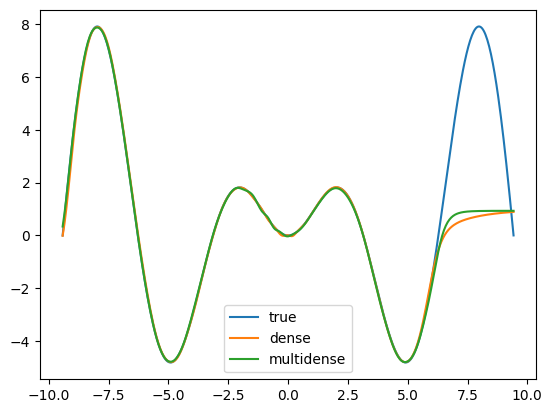

In [11]:
plt.plot(x_test, y_true, label="true")
plt.plot(x_test, y_pred_dense, label="dense")
plt.plot(x_test, y_pred_multidense, label="multidense")
plt.legend()
plt.show()


---